# Otimização Multi-Objetivo e NSGA

## Introdução

A otimização multi-objetivo é o processo de encontrar soluções para problemas que envolvem **múltiplos objetivos conflitantes**. Diferentemente da otimização com um único objetivo, aqui não há uma solução única "ótima". Em vez disso, busca-se um conjunto de soluções chamadas de **fronteira de Pareto**, onde nenhuma solução pode ser melhorada em um objetivo sem piorar outro.

Neste notebook, apresentamos um exemplo com dois objetivos aplicados a uma única variável. Trata-se de um caso simples, mas extremamente útil para compreender o funcionamento dos algoritmos **NSGA**. A simplicidade do exemplo permite a visualização geométrica e uma compreensão intuitiva dos resultados, facilitando a análise e a interpretação da fronteira de Pareto gerada.

## Conceitos Fundamentais

### Problema Multiobjetivo

Um problema de otimização multiobjetivo pode ser formalmente descrito como:

$$
\min_{x \in X} \; F(x) = \big(f_1(x), f_2(x), \dots, f_M(x)\big),
$$

onde:
- $X \subseteq \mathbb{R}^n$ representa o **espaço de decisão**, ou seja, o conjunto de todas as soluções possíveis;
- $F(x)$ é um vetor de $M$ funções objetivo, cada uma $f_i : X \rightarrow \mathbb{R}$, para $i = 1, \dots, M$;
- o objetivo é encontrar o conjunto de soluções **Pareto-ótimas**, isto é, soluções em que nenhuma melhora em um objetivo pode ser alcançada sem piorar pelo menos outro.

Em geral, um problema pode envolver objetivos de minimização e de maximização. Para simplificar a análise, consideraremos apenas objetivos de **minimização**, uma vez que qualquer objetivo de maximização pode ser convertido em um de minimização pela negação de sua função.

### Definição: Espaço de Objetivos

Seja $F(x) = (f_1(x), \dots, f_M(x))$ um vetor de $M$ funções objetivo definidas em um domínio $X \subseteq \mathbb{R}^n$. O **espaço de objetivos** é o conjunto de pontos de $\mathbb{R}^M$ alcançáveis por $F$ quando avaliada sobre $X$, isto é:

$$
Y = F(X) = \{\, F(x) \in \mathbb{R}^M \mid x \in X \,\},
$$

onde $Y \subseteq \mathbb{R}^M$.

### Definição: Dominância de Pareto

Em um problema de minimização, uma solução $x_1$ **domina** outra solução $x_2$ quando é **não pior em todos os objetivos** e **estritamente melhor em pelo menos um objetivo**. Nesse caso, denotamos $x_1 \prec x_2$ e dizemos que $y_1 = F(x_1)$ domina $y_2 = F(x_2)$. Formalmente, para $M$ objetivos:

$$
x_1 \prec x_2 \quad\Longleftrightarrow\quad
\begin{cases}
f_i(x_1) \le f_i(x_2), & \text{para todo } i \in \{1, \dots, M\}, \\[4pt]
f_i(x_1) < f_i(x_2), & \text{para algum } i \in \{1, \dots, M\}.
\end{cases}
$$

### Definição: Conjunto Pareto-ótimo e Fronteira de Pareto

Uma solução é **Pareto-ótima** quando não é dominada por nenhuma outra solução viável. O **conjunto Pareto-ótimo** (ou *conjunto eficiente*) $X^*$ reúne todas essas soluções no espaço de decisão:

$$
X^* := \{\, x^* \in X \mid \nexists\, x \in X,\; x \prec x^* \,\}.
$$

A **Fronteira de Pareto** $P$ é a imagem de $X^*$ no espaço de objetivos:

$$
P := \{\, F(x^*) \mid x^* \in X^* \,\} \subseteq Y.
$$

## Exemplo com duas Funções Quadráticas

Vamos considerar um problema simples com duas funções objetivo:

$$
f_1(x) = (x - 2)^2
$$

$$
f_2(x) = (x + 2)^2
$$

queremos encontrar $x$ que minimiza $f_1$ e $f_2$ ao mesmo tempo.

**Análise do Problema**

1. $f_1(x)$: É uma função quadrática que atinge seu mínimo quando $x = 2$.

2. $f_2(x)$: É uma função quadrática que atinge seu mínimo quando $x = -2$.

3. Os objetivos estão em conflito, pois minimizando $f_1(x)$ (levando $x$ para 2) aumentamos $f_2(x)$, e vice-versa.

**Interpretação Geométrica**

- Para valores de $x$ intermediários entre $-2$ e $2$, nenhum dos objetivos é minimizado ao extremo.

- O conjunto de soluções Pareto-ótimas é o intervalo $x \in [-2, 2]$, pois cada ponto nesse intervalo representa um compromisso entre os dois objetivos.

### Espaço de Objetivos do Exemplo

Para o caso específico com

$$
f_1(x) = (x-2)^2, \qquad f_2(x) = (x+2)^2,
$$

e supondo $x \in X = [a, b] \subset \mathbb{R}$, o espaço de objetivos é

$$
Y = F(X) = \{\, (f_1(x), f_2(x)) \mid x \in [a, b] \,\} \subseteq \mathbb{R}^2.
$$

Trata-se de uma **curva** no plano $\mathbb{R}^2$, formada pelas imagens do par $(f_1(x), f_2(x))$ à medida que $x$ percorre o domínio $X$.

### Configuração

A célula abaixo importa as bibliotecas e define, uma única vez, as funções objetivo $f_1$ e $f_2$, o vetor $F = (f_1, f_2)$ e o domínio $X = [-10, 10]$ da variável de decisão. Esses elementos são reutilizados em todo o restante do notebook.

In [1]:
# Configuração: bibliotecas, funções objetivo do exemplo e domínio.
import math
import random

import numpy as np
import matplotlib.pyplot as plt


def f1(x):
    return (x - 2) ** 2


def f2(x):
    return (x + 2) ** 2


# F(x) = (f_1(x), f_2(x)); domínio X = [-10, 10] da variável de decisão.
OBJECTIVES = (f1, f2)
BOUNDS = (-10.0, 10.0)

O código a seguir realiza o plot dos gráficos das funções objetivo $f_1$ e $f_2$ no espaço de decisão e a correspondente fronteira de Pareto no espaço de objetivos.  

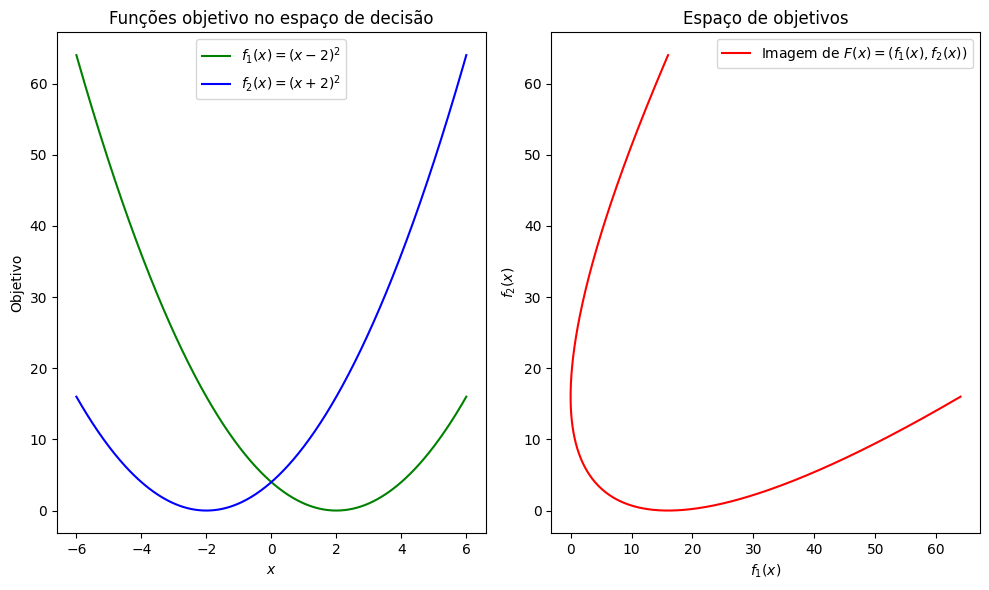

In [2]:
# f1, f2 e o domínio já foram definidos na célula de configuração.
x = np.linspace(-6, 6, 500)

plt.figure(figsize=(10, 6))

# Funções objetivo no espaço de decisão
plt.subplot(1, 2, 1)
plt.plot(x, f1(x), label="$f_1(x) = (x-2)^2$", color="green")
plt.plot(x, f2(x), label="$f_2(x) = (x+2)^2$", color="blue")
plt.title("Funções objetivo no espaço de decisão")
plt.xlabel("$x$")
plt.ylabel("Objetivo")
plt.legend()

# Imagem de F no espaço de objetivos
plt.subplot(1, 2, 2)
plt.plot(f1(x), f2(x), label=r"Imagem de $F(x)=(f_1(x),f_2(x))$", color="red")
plt.title("Espaço de objetivos")
plt.xlabel("$f_1(x)$")
plt.ylabel("$f_2(x)$")
plt.legend()

plt.tight_layout()
plt.show()

Agora observe que os pontos extremos das funções objetivo, delimitam a fronteira de Pareto. A seguir apresentamos um plot indicando estes pontos no espaço de decisão e no espaço de objetivos.

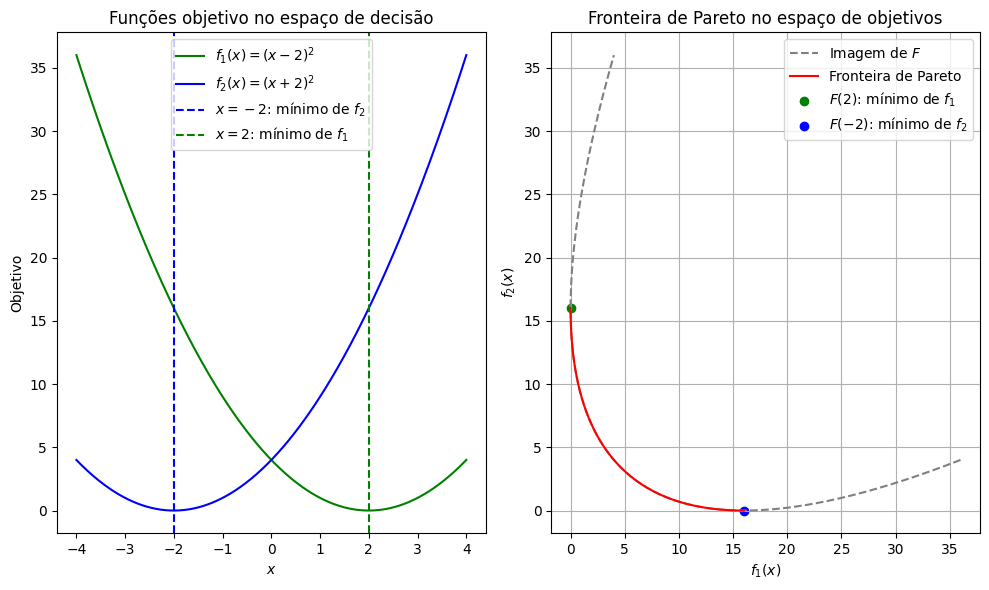

In [3]:
x = np.linspace(-4, 4, 500)
x_pareto = np.linspace(-2, 2, 500)   # conjunto Pareto-ótimo: x em [-2, 2]

plt.figure(figsize=(10, 6))

# Espaço de decisão
plt.subplot(1, 2, 1)
plt.plot(x, f1(x), label="$f_1(x) = (x-2)^2$", color="green")
plt.plot(x, f2(x), label="$f_2(x) = (x+2)^2$", color="blue")
plt.axvline(-2, linestyle="--", color="blue", label="$x=-2$: mínimo de $f_2$")
plt.axvline(2, linestyle="--", color="green", label="$x=2$: mínimo de $f_1$")
plt.title("Funções objetivo no espaço de decisão")
plt.xlabel("$x$")
plt.ylabel("Objetivo")
plt.legend()

# Espaço de objetivos
plt.subplot(1, 2, 2)
plt.plot(f1(x), f2(x), linestyle="--", label=r"Imagem de $F$", color="gray")
plt.plot(f1(x_pareto), f2(x_pareto), label="Fronteira de Pareto", color="red")
plt.scatter(f1(2), f2(2), color="green", label="$F(2)$: mínimo de $f_1$")
plt.scatter(f1(-2), f2(-2), color="blue", label="$F(-2)$: mínimo de $f_2$")
plt.title("Fronteira de Pareto no espaço de objetivos")
plt.xlabel("$f_1(x)$")
plt.ylabel("$f_2(x)$")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Como ambos os objetivos são de **minimização**, a região dominada por um ponto $\mathbf{p}=(p_1,p_2)$ corresponde aos pontos localizados à sua direita e acima:

$$
\mathcal{D}(\mathbf{p})=
\{
z\in\mathbb{R}^2:
z_1\geq p_1,\;
z_2\geq p_2
\}.
$$

O código abaixo destaca as regiões dominadas pelos dois extremos da fronteira e pelo ponto intermediário associado a (x=0):

Os três pontos destacados são:

$$
F(-2)=(16,0),\qquad
F(0)=(4,4),\qquad
F(2)=(0,16).
$$

Assim, por exemplo, a região dominada pelo ponto intermediário é

$$
\mathcal{D}(F(0))=
\{
(z_1,z_2):z_1\geq 4,\;z_2\geq 4
\}.
$$

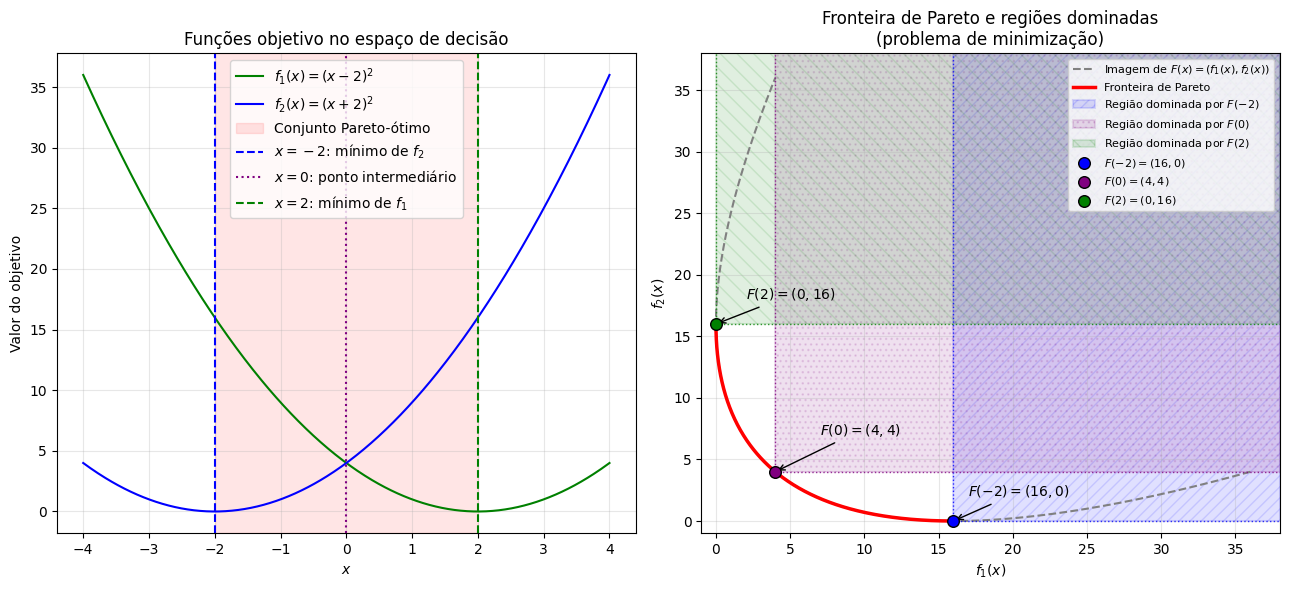

In [4]:
from matplotlib.patches import Rectangle

# numpy (np), matplotlib (plt) e as funções f1, f2 vêm da configuração.

x = np.linspace(-4, 4, 500)

f1_vals = f1(x)
f2_vals = f2(x)

# Para este problema, as soluções Pareto-ótimas estão no intervalo [-2, 2].
x_pareto = np.linspace(-2, 2, 500)

pareto_f1_vals = f1(x_pareto)
pareto_f2_vals = f2(x_pareto)

# Extremo que minimiza f2.
x_left = -2
point_left = (f1(x_left), f2(x_left))

# Ponto intermediário da fronteira.
x_middle = 0
point_middle = (f1(x_middle), f2(x_middle))

# Extremo que minimiza f1.
x_right = 2
point_right = (f1(x_right), f2(x_right))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax_decision = axes[0]

ax_decision.plot(
    x,
    f1_vals,
    label=r"$f_1(x)=(x-2)^2$",
    color="green",
)

ax_decision.plot(
    x,
    f2_vals,
    label=r"$f_2(x)=(x+2)^2$",
    color="blue",
)

ax_decision.axvspan(
    -2,
    2,
    alpha=0.10,
    color="red",
    label="Conjunto Pareto-ótimo",
)

ax_decision.axvline(
    -2,
    linestyle="--",
    color="blue",
    label=r"$x=-2$: mínimo de $f_2$",
)

ax_decision.axvline(
    0,
    linestyle=":",
    color="purple",
    label=r"$x=0$: ponto intermediário",
)

ax_decision.axvline(
    2,
    linestyle="--",
    color="green",
    label=r"$x=2$: mínimo de $f_1$",
)

ax_decision.set_title("Funções objetivo no espaço de decisão")
ax_decision.set_xlabel(r"$x$")
ax_decision.set_ylabel("Valor do objetivo")
ax_decision.grid(alpha=0.3)
ax_decision.legend()

ax_objective = axes[1]

ax_objective.plot(
    f1_vals,
    f2_vals,
    linestyle="--",
    color="gray",
    label=r"Imagem de $F(x)=(f_1(x),f_2(x))$",
)

ax_objective.plot(
    pareto_f1_vals,
    pareto_f2_vals,
    linewidth=2.5,
    color="red",
    label="Fronteira de Pareto",
)

# Limites escolhidos antes da criação das regiões dominadas.
objective_max = max(
    np.max(f1_vals),
    np.max(f2_vals),
) + 2

ax_objective.set_xlim(-1, objective_max)
ax_objective.set_ylim(-1, objective_max)


def add_dominated_region(
    ax,
    point,
    color,
    label,
    hatch=None,
):
    """
    Adiciona a região dominada pelo ponto no caso de minimização.

    Um ponto p = (p1, p2) domina todos os pontos z = (z1, z2)
    tais que z1 >= p1 e z2 >= p2, com pelo menos uma desigualdade
    estrita.
    """
    p1, p2 = point

    region = Rectangle(
        (p1, p2),
        objective_max - p1,
        objective_max - p2,
        facecolor=color,
        edgecolor=color,
        alpha=0.12,
        hatch=hatch,
        linewidth=1.5,
        label=label,
        zorder=1,
    )

    ax.add_patch(region)

    # Linhas auxiliares que identificam o vértice da região.
    ax.plot(
        [p1, objective_max],
        [p2, p2],
        linestyle=":",
        color=color,
        alpha=0.8,
        linewidth=1,
    )

    ax.plot(
        [p1, p1],
        [p2, objective_max],
        linestyle=":",
        color=color,
        alpha=0.8,
        linewidth=1,
    )


# Regiões dominadas pelos pontos selecionados.
add_dominated_region(
    ax_objective,
    point_left,
    color="blue",
    label=r"Região dominada por $F(-2)$",
    hatch="///",
)

add_dominated_region(
    ax_objective,
    point_middle,
    color="purple",
    label=r"Região dominada por $F(0)$",
    hatch="...",
)

add_dominated_region(
    ax_objective,
    point_right,
    color="green",
    label=r"Região dominada por $F(2)$",
    hatch="\\\\",
)

# Pontos selecionados.
ax_objective.scatter(
    *point_left,
    color="blue",
    s=70,
    edgecolor="black",
    zorder=5,
    label=r"$F(-2)=(16,0)$",
)

ax_objective.scatter(
    *point_middle,
    color="purple",
    s=70,
    edgecolor="black",
    zorder=5,
    label=r"$F(0)=(4,4)$",
)

ax_objective.scatter(
    *point_right,
    color="green",
    s=70,
    edgecolor="black",
    zorder=5,
    label=r"$F(2)=(0,16)$",
)

# Anotações.
ax_objective.annotate(
    r"$F(-2)=(16,0)$",
    xy=point_left,
    xytext=(17, 2),
    arrowprops={"arrowstyle": "->"},
)

ax_objective.annotate(
    r"$F(0)=(4,4)$",
    xy=point_middle,
    xytext=(7, 7),
    arrowprops={"arrowstyle": "->"},
)

ax_objective.annotate(
    r"$F(2)=(0,16)$",
    xy=point_right,
    xytext=(2, 18),
    arrowprops={"arrowstyle": "->"},
)

ax_objective.set_title(
    "Fronteira de Pareto e regiões dominadas\n"
    "(problema de minimização)"
)

ax_objective.set_xlabel(r"$f_1(x)$")
ax_objective.set_ylabel(r"$f_2(x)$")
ax_objective.grid(alpha=0.3)
ax_objective.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## Operadores Comuns aos Algoritmos NSGA

As três variantes do NSGA compartilham a mesma estrutura de algoritmo genético: representação das soluções, avaliação, teste de dominância, ordenação em fronteiras não dominadas e os operadores de cruzamento e mutação. Para evitar repetição e destacar, em cada algoritmo, **apenas o que lhe é próprio**, definimos esses elementos uma única vez na célula abaixo.

Cada implementação (`nsga`, `nsga2`, `nsga3`) reutiliza esses operadores e acrescenta somente a sua estratégia característica de **seleção** e de **preservação da diversidade**:

| Função | Papel |
| --- | --- |
| `initialize_population`, `evaluate_population` | representação e avaliação de $F$ |
| `dominates`, `fast_nondominated_sort` | dominância de Pareto e ordenação em fronteiras |
| `arithmetic_crossover`, `mutate` | operadores genéticos |
| `extract_pareto_front`, `plot_pareto` | extração e visualização do resultado |

In [5]:
# Operadores reutilizados pelos três algoritmos. Assim, cada bloco de
# algoritmo abaixo implementa apenas o que lhe é próprio: a estratégia de
# seleção e o mecanismo de preservação da diversidade.

# --- Representação e avaliação ---------------------------------------------
def initialize_population(size, bounds):
    """População inicial aleatória e uniforme no domínio."""
    lower, upper = bounds
    return [random.uniform(lower, upper) for _ in range(size)]


def evaluate_population(population, objective_functions=OBJECTIVES):
    """Avalia F(x) = (f_1(x), ..., f_M(x)) para cada indivíduo."""
    return [
        tuple(objective(individual) for objective in objective_functions)
        for individual in population
    ]


# --- Dominância de Pareto (minimização) ------------------------------------
def dominates(a, b):
    """True se `a` domina `b`: não pior em nenhum objetivo e melhor em ao menos um."""
    no_worse = all(ai <= bi for ai, bi in zip(a, b))
    strictly_better = any(ai < bi for ai, bi in zip(a, b))
    return no_worse and strictly_better


# --- Ordenação em fronteiras não dominadas (fast non-dominated sort) --------
def fast_nondominated_sort(objectives):
    """Separa a população em fronteiras não dominadas. Retorna (fronts, ranks)."""
    n = len(objectives)
    domination_count = [0] * n           # nº de soluções que dominam cada indivíduo
    dominated = [[] for _ in range(n)]   # soluções dominadas por cada indivíduo
    ranks = [0] * n
    fronts = [[]]

    for p in range(n):
        for q in range(p + 1, n):
            if dominates(objectives[p], objectives[q]):
                dominated[p].append(q)
                domination_count[q] += 1
            elif dominates(objectives[q], objectives[p]):
                dominated[q].append(p)
                domination_count[p] += 1

    for p in range(n):
        if domination_count[p] == 0:     # não dominado => primeira fronteira
            ranks[p] = 0
            fronts[0].append(p)

    i = 0
    while i < len(fronts) and fronts[i]:
        next_front = []
        for p in fronts[i]:
            for q in dominated[p]:
                domination_count[q] -= 1
                if domination_count[q] == 0:
                    ranks[q] = i + 1
                    next_front.append(q)
        if next_front:
            fronts.append(next_front)
        i += 1

    return fronts, ranks


# --- Operadores genéticos ---------------------------------------------------
def arithmetic_crossover(parent1, parent2):
    """Cruzamento aritmético: produz dois descendentes complementares."""
    beta = random.random()
    child1 = beta * parent1 + (1.0 - beta) * parent2
    child2 = (1.0 - beta) * parent1 + beta * parent2
    return child1, child2


def mutate(individual, bounds, mutation_rate=0.2, mutation_scale=0.05):
    """Perturbação uniforme (prob. mutation_rate) mantendo o indivíduo no domínio."""
    lower, upper = bounds
    if random.random() < mutation_rate:
        step = mutation_scale * (upper - lower)
        individual += random.uniform(-step, step)
    return float(np.clip(individual, lower, upper))


# --- Resultado e visualização ----------------------------------------------
def extract_pareto_front(population, objective_functions=OBJECTIVES):
    """Fronteira não dominada (front 0) da população, ordenada por f_1."""
    objectives = evaluate_population(population, objective_functions)
    fronts, _ = fast_nondominated_sort(objectives)
    front = [objectives[i] for i in fronts[0]]
    front.sort(key=lambda point: point[0])
    return front


def plot_pareto(pareto_front, algorithm_label):
    """Compara a fronteira obtida com a fronteira de Pareto teórica do exemplo."""
    x = np.linspace(-2, 2, 500)
    plt.figure(figsize=(6, 6))
    plt.plot(f1(x), f2(x), color="blue", label="Fronteira de Pareto teórica")
    plt.scatter(*zip(*pareto_front), color="red",
                label=f"Fronteira obtida ({algorithm_label})")
    plt.title(f"Fronteira de Pareto: teórica vs. {algorithm_label}")
    plt.xlabel("$f_1(x)$")
    plt.ylabel("$f_2(x)$")
    plt.grid()
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Introdução ao NSGA (Non-dominated Sorting Genetic Algorithm)

O **NSGA** (*Non-dominated Sorting Genetic Algorithm*) é um algoritmo evolutivo desenvolvido para problemas de otimização multiobjetivo. Seu objetivo é encontrar, em uma única execução, um conjunto diversificado de soluções que forneça uma boa aproximação da **fronteira de Pareto**.

Assim como outros algoritmos genéticos, o NSGA evolui uma população de soluções por meio de mecanismos de seleção, cruzamento e mutação. Sua principal contribuição consiste em incorporar ao processo evolutivo dois critérios específicos da otimização multiobjetivo:

1. a classificação das soluções em fronteiras não dominadas;
2. a preservação da diversidade por meio de *fitness sharing*.

Embora tenha sido posteriormente sucedido pelo **NSGA-II**, o NSGA introduziu conceitos fundamentais que permanecem presentes em diversos algoritmos evolutivos multiobjetivo.

### Funcionamento do NSGA

1. **Inicialização da população**

   * Gera-se aleatoriamente uma população inicial de tamanho (N).
   * Cada indivíduo representa uma solução no espaço de decisão.
   * Todos os indivíduos são avaliados nas funções objetivo do problema.

2. **Ordenação não dominada**

   * A população é separada em sucessivas fronteiras de dominância:

     * **Primeira fronteira**: contém as soluções que não são dominadas por nenhuma outra solução da população;
     * **Segunda fronteira**: contém as soluções que se tornam não dominadas após a remoção da primeira fronteira;
     * **Fronteiras seguintes**: são construídas repetindo-se o mesmo procedimento.
   * Cada indivíduo recebe, portanto, um nível ou *rank* de dominância. Quanto menor o rank, melhor é sua posição no processo de seleção.

3. **Atribuição da aptidão**

   * Os indivíduos da primeira fronteira recebem os maiores valores de aptidão.
   * As fronteiras seguintes recebem valores progressivamente menores, garantindo que soluções de uma fronteira superior tenham preferência sobre soluções pertencentes a fronteiras inferiores.
   * Dessa forma, soluções menos dominadas possuem maior probabilidade de participar da reprodução.

4. **Preservação da diversidade por *fitness sharing***

   * Dentro de cada fronteira, calcula-se a proximidade entre os indivíduos.
   * Soluções localizadas em regiões muito densas têm sua aptidão reduzida, enquanto soluções mais isoladas mantêm maior potencial reprodutivo.
   * Esse mecanismo, denominado *fitness sharing*, busca distribuir as soluções ao longo da fronteira de Pareto e evitar que a população se concentre em uma pequena região do espaço de objetivos.
   * Diferentemente do NSGA-II, o NSGA original não utiliza *crowding distance*.

5. **Seleção dos pais**

   * A seleção é realizada com base na aptidão ajustada.
   * Indivíduos pertencentes às melhores fronteiras tendem a aparecer mais vezes no conjunto de reprodução.
   * Dentro de uma mesma fronteira, o *fitness sharing* favorece indivíduos localizados em regiões menos densamente ocupadas.

6. **Aplicação dos operadores genéticos**

   * **Cruzamento**: combina características de dois indivíduos selecionados para produzir novos descendentes.
   * **Mutação**: introduz pequenas alterações aleatórias nos descendentes, aumentando a variabilidade da população e permitindo a exploração de novas regiões do espaço de decisão.

7. **Substituição da população**

   * Os descendentes produzidos formam a população da geração seguinte.
   * Na implementação didática apresentada, ocorre uma substituição geracional: a população anterior é substituída pela nova população.
   * Portanto, não é realizada a união elitista entre pais e descendentes, mecanismo que será introduzido posteriormente no NSGA-II.

8. **Iteração**

   * O processo de avaliação, ordenação não dominada, atribuição de aptidão, seleção, cruzamento e mutação é repetido durante várias gerações.
   * Ao longo da evolução, espera-se que a população se aproxime progressivamente da fronteira de Pareto, mantendo uma distribuição razoavelmente diversificada de soluções.

Para fins didáticos, apresentamos a seguir uma implementação simplificada do NSGA. Ela conserva os principais elementos conceituais do algoritmo original — ordenação não dominada, atribuição de aptidão por fronteiras, *fitness sharing* e seleção proporcional —, mas emprega operadores genéticos simples e uma representação composta por apenas uma variável de decisão.

Embora essa implementação não seja adequada para problemas complexos, de alta dimensão ou de grande escala, ela é suficiente para ilustrar o funcionamento do algoritmo e obter boas aproximações da fronteira de Pareto em problemas pequenos, como o exemplo formado por duas funções objetivo quadráticas.

In [6]:
def nsga(pop_size, generations, bounds,
         mutation_rate=0.2, mutation_scale=0.05,
         sigma_share=0.10, alpha_share=2.0):
    """NSGA original: fitness sharing + seleção proporcional + substituição geracional.

    O que distingue o NSGA (e é implementado aqui) é a atribuição de aptidão
    por fronteiras combinada ao *fitness sharing*. Ordenação, cruzamento e
    mutação vêm dos operadores comuns.
    """
    lower, upper = bounds
    decision_range = upper - lower

    def sharing(distance):
        """Função de compartilhamento no espaço de decisão."""
        if distance >= sigma_share:
            return 0.0
        return 1.0 - (distance / sigma_share) ** alpha_share

    def shared_fitness(population, fronts):
        """Aptidão por fronteira, reduzida pela densidade local (niche count)."""
        fitness = [0.0] * len(population)
        base = float(pop_size)                       # aptidão base da fronteira atual
        for front in fronts:
            niche = {
                i: max(sum(sharing(abs(population[i] - population[j]) / decision_range)
                           for j in front), 1e-12)
                for i in front
            }
            for i in front:
                fitness[i] = base / niche[i]         # regiões densas => menor aptidão
            # a próxima fronteira recebe aptidão estritamente menor
            base = max(min(fitness[i] for i in front) - 1e-12, 1e-12)
        return fitness

    population = initialize_population(pop_size, bounds)
    for _ in range(generations):
        objectives = evaluate_population(population)
        fronts, _ = fast_nondominated_sort(objectives)
        fitness = shared_fitness(population, fronts)

        # seleção proporcional à aptidão (roleta)
        mating_pool = random.choices(population, weights=fitness, k=pop_size)

        offspring = []
        for k in range(0, pop_size, 2):
            child1, child2 = arithmetic_crossover(mating_pool[k],
                                                  mating_pool[(k + 1) % pop_size])
            offspring.append(mutate(child1, bounds, mutation_rate, mutation_scale))
            if len(offspring) < pop_size:
                offspring.append(mutate(child2, bounds, mutation_rate, mutation_scale))

        population = offspring          # substituição geracional (sem elitismo)

    return extract_pareto_front(population)

A seguir, apresentamos o resultado da execução do algoritmo, com os pontos obtidos sobrepostos à curva correspondente à fronteira de Pareto exata.

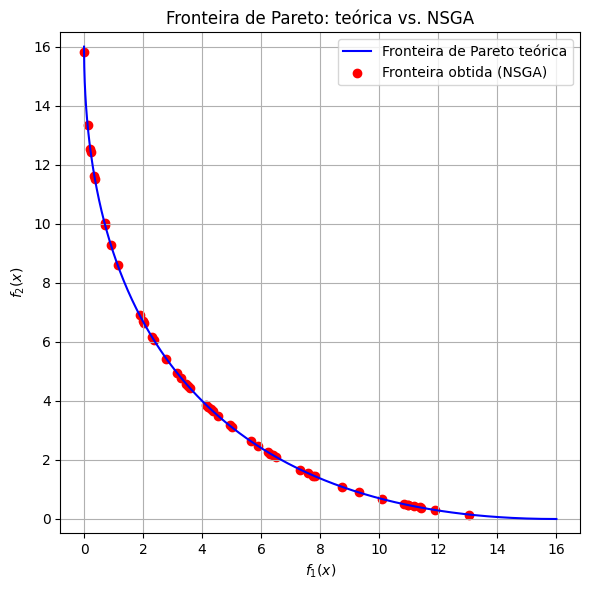

In [7]:
# Executa o NSGA e compara com a fronteira de Pareto teórica.
pareto_front = nsga(pop_size=50, generations=10, bounds=BOUNDS)
plot_pareto(pareto_front, "NSGA")

## Introdução ao NSGA-II

O **NSGA-II** (*Non-dominated Sorting Genetic Algorithm II*) aprimora o NSGA original por meio de três modificações principais:

1. **Ordenação não dominada mais eficiente**
   O procedimento de classificação das soluções reduz a complexidade computacional de $O(MN^3)$ para $O(MN^2)$, em que $N$ representa o tamanho da população e $M$ o número de funções objetivo.

2. **Preservação da diversidade por *crowding distance***
   O mecanismo de *fitness sharing* empregado pelo NSGA original é substituído pela *crowding distance*. Essa métrica estima a densidade de soluções ao redor de cada indivíduo no espaço de objetivos, favorecendo soluções localizadas em regiões menos densamente ocupadas. Com isso, o NSGA-II dispensa a definição de parâmetros de compartilhamento, como o raio $\sigma_{\text{share}}$.

3. **Seleção ambiental elitista**
   A população atual é combinada com a população de descendentes. Em seguida, as melhores soluções dessa população conjunta são selecionadas para compor a geração seguinte. Esse procedimento reduz a possibilidade de perda das melhores soluções já encontradas e favorece a convergência em direção à fronteira de Pareto.

### Funcionamento do NSGA-II

1. **Inicialização da população**

   * Gera-se aleatoriamente uma população inicial $P_0$ de tamanho $N$.
   * Cada indivíduo representa uma solução no espaço de decisão.
   * Todos os indivíduos são avaliados nas funções objetivo do problema.

2. **Ordenação não dominada**

   * A população é classificada em sucessivas fronteiras não dominadas:

     * **Primeira fronteira**: contém as soluções que não são dominadas por nenhuma outra solução da população;
     * **Segunda fronteira**: contém as soluções que se tornam não dominadas após a remoção da primeira fronteira;
     * **Fronteiras seguintes**: são construídas repetindo-se o mesmo procedimento.
   * Cada indivíduo recebe um *rank* correspondente à fronteira à qual pertence. Quanto menor o rank, melhor é sua classificação.

3. **Cálculo da *crowding distance***

   * Para cada fronteira, as soluções são ordenadas separadamente de acordo com cada função objetivo.
   * As soluções extremas recebem distância infinita, de modo que os limites conhecidos da fronteira sejam preservados.
   * Para as demais soluções, a distância é estimada pela soma das diferenças normalizadas entre seus vizinhos mais próximos em cada objetivo.
   * Uma *crowding distance* elevada indica que o indivíduo está localizado em uma região menos densa do espaço de objetivos.

4. **Seleção dos pais**

   * Os pais são selecionados por torneio binário.
   * Dois indivíduos são comparados por meio do operador de comparação do NSGA-II:

     * o indivíduo com menor rank é preferido;
     * se ambos pertencem à mesma fronteira, é preferido aquele com maior *crowding distance*;
     * em caso de empate completo, a escolha pode ser realizada aleatoriamente.
   * Dessa forma, a seleção privilegia simultaneamente a convergência e a diversidade.

5. **Aplicação dos operadores genéticos**

   * **Cruzamento**: combina as características de dois indivíduos selecionados para produzir novos descendentes.
   * **Mutação**: introduz pequenas perturbações aleatórias nos descendentes, aumentando a variabilidade e permitindo a exploração de novas regiões do espaço de decisão.
   * Os operadores genéticos produzem uma população de descendentes $Q_t$, também de tamanho $N$.

6. **Combinação entre pais e descendentes**

   * A população atual $P_t$ é combinada com a população de descendentes $Q_t$:

$$
R_t = P_t \cup Q_t.
$$

* A população combinada $R_t$ possui, portanto, até $2N$ indivíduos.
* Todos os indivíduos dessa população são novamente classificados em fronteiras não dominadas.

7. **Seleção ambiental elitista**

   * As fronteiras de $R_t$ são inseridas integralmente na população seguinte, começando pela primeira fronteira.
   * Esse processo continua enquanto a inclusão completa da próxima fronteira não ultrapassar o limite de $N$ indivíduos.
   * Quando a última fronteira considerada não cabe integralmente, seus indivíduos são ordenados por *crowding distance*.
   * As soluções com maiores distâncias são selecionadas até completar a nova população $P_{t+1}$.
   * Como pais e descendentes competem conjuntamente, boas soluções encontradas em gerações anteriores podem ser preservadas.

8. **Iteração**

   * O processo de seleção de pais, cruzamento, mutação, combinação populacional e seleção ambiental é repetido durante várias gerações.
   * Ao longo da evolução, espera-se que a população se aproxime progressivamente da fronteira de Pareto e permaneça distribuída ao longo de suas diferentes regiões.

9. **Resultado**

   * Após o número definido de gerações, a primeira fronteira não dominada da população final é utilizada como aproximação da fronteira de Pareto.
   * Essas soluções representam diferentes compromissos entre os objetivos conflitantes, sem que uma delas seja simultaneamente melhor que as demais em todos os objetivos.

O fluxo principal do NSGA-II pode ser resumido por:

$$
P_t
\longrightarrow
Q_t
\longrightarrow
R_t = P_t \cup Q_t
\longrightarrow
P_{t+1}.
$$

A principal diferença em relação ao NSGA original está na forma de preservar a diversidade e realizar a substituição populacional. Enquanto o NSGA utiliza *fitness sharing* e substituição geracional, o NSGA-II emprega *crowding distance* e seleção ambiental elitista sobre a união entre pais e descendentes.

#### Distância de *Crowding*

Para preservar a diversidade da população, o NSGA-II utiliza a *crowding distance*, uma métrica heurística que estima o grau de isolamento de cada solução no espaço de objetivos. Intuitivamente, quanto maior a *crowding distance* de uma solução, menor é a densidade de soluções em sua vizinhança.

A distância é calculada separadamente dentro de cada fronteira não dominada. Seja $F$ uma fronteira contendo $n$ soluções e seja $M$ o número de funções objetivo. Para cada solução $i \in F$, sua *crowding distance* é inicialmente definida como

$$
d_i = 0.
$$

Em seguida, para cada objetivo $f_m$, com $m = 1,\ldots,M$, as soluções da fronteira são ordenadas em ordem crescente segundo seus valores nesse objetivo:

$$
f_{m,1} \leq f_{m,2} \leq \cdots \leq f_{m,n}.
$$

Nessa ordenação, $f_{m,i}$ representa o valor do objetivo $f_m$ para a solução que ocupa a posição $i$.

Para cada solução interna, isto é, para $i = 2,\ldots,n-1$, a contribuição do objetivo $m$ para a *crowding distance* é dada por

$$
d_i^m =
\frac{
f_{m,i+1} - f_{m,i-1}
}{
f_{m,\max} - f_{m,\min}
},
$$

em que

$$
f_{m,\min} = f_{m,1}
$$

e

$$
f_{m,\max} = f_{m,n}.
$$

A *crowding distance* total da solução corresponde à soma das contribuições calculadas para todos os objetivos:

$$
d_i = \sum_{m=1}^{M} d_i^m.
$$

Assim, uma solução recebe uma distância elevada quando existe uma grande separação entre seus vizinhos no espaço de objetivos. Por outro lado, soluções localizadas em regiões densamente ocupadas tendem a apresentar valores menores de $d_i$.

##### Interpretação dos termos

1. **$f_{m,i}$**

   * Representa o valor da $m$-ésima função objetivo para a solução que ocupa a posição $i$ após a ordenação da fronteira em relação a $f_m$.

2. **$f_{m,i-1}$ e $f_{m,i+1}$**

   * Representam os valores do objetivo $f_m$ para as soluções imediatamente anterior e posterior a $i$ na ordenação associada ao objetivo $m$.

3. **$f_{m,\min}$ e $f_{m,\max}$**

   * Representam, respectivamente, o menor e o maior valor do objetivo $f_m$ dentro da fronteira considerada.

4. **Normalização**

   * A diferença entre os valores dos vizinhos é dividida pela amplitude do objetivo:

$$
f_{m,\max} - f_{m,\min}.
$$

* Essa normalização reduz a influência das diferentes escalas das funções objetivo sobre o cálculo da distância.

#### Casos especiais

##### Soluções extremas

Para cada objetivo $f_m$, as soluções localizadas nas extremidades da ordenação recebem distância infinita:

$$
d_1^m = d_n^m = \infty.
$$

Consequentemente, a distância total dessas soluções também é infinita:

$$
d_1 = d_n = \infty.
$$

Esse procedimento favorece a preservação das soluções extremas da fronteira, evitando que os limites da região conhecida de compromissos sejam eliminados durante a seleção ambiental.

Como a ordenação é realizada separadamente para cada objetivo, uma solução pode ser extrema em um objetivo sem ser extrema nos demais. Basta que ela seja extrema em pelo menos um dos objetivos para que sua *crowding distance* total seja infinita.

##### Fronteiras com até duas soluções

Quando uma fronteira contém uma ou duas soluções, não existem vizinhos suficientes para calcular a expressão baseada nas soluções anterior e posterior. Nesse caso, todas as soluções da fronteira recebem distância infinita:

$$
d_i = \infty,
\qquad
i = 1,\ldots,n,
\qquad
n \leq 2.
$$

##### Objetivos sem variação

Se todas as soluções da fronteira apresentam o mesmo valor para determinado objetivo $f_m$, então

$$
f_{m,\max} - f_{m,\min} = 0.
$$

Nesse caso, o objetivo não fornece informação para distinguir a densidade local das soluções e sua contribuição para as soluções internas deve ser considerada nula:

$$
d_i^m = 0.
$$

Isso também evita uma divisão por zero durante o cálculo.

#### Algoritmo para o cálculo da *crowding distance*

O procedimento pode ser resumido nos seguintes passos:

1. Inicializar a distância de todas as soluções da fronteira:

$$
d_i = 0,
\qquad
i = 1,\ldots,n.
$$

2. Para cada objetivo $f_m$, ordenar as soluções da fronteira de modo que

$$
f_{m,1} \leq f_{m,2} \leq \cdots \leq f_{m,n}.
$$

3. Atribuir distância infinita às soluções extremas da ordenação:

$$
d_1 = d_n = \infty.
$$

4. Para cada solução interna, calcular a contribuição normalizada do objetivo:

$$
d_i^m =
\frac{
f_{m,i+1} - f_{m,i-1}
}{
f_{m,\max} - f_{m,\min}
},
\qquad
i = 2,\ldots,n-1.
$$

5. Acumular essa contribuição na distância total da solução:

$$
d_i \leftarrow d_i + d_i^m.
$$

O procedimento é repetido para todos os $M$ objetivos. Ao final, soluções com maior *crowding distance* são consideradas preferíveis quando comparadas a outras soluções pertencentes à mesma fronteira, pois representam regiões menos densamente ocupadas do espaço de objetivos.

A seguir, apresentamos uma implementação didática do NSGA-II, destacando a ordenação não dominada, o cálculo da *crowding distance*, a seleção por torneio e a seleção ambiental elitista.

In [8]:
def nsga2(pop_size, generations, bounds,
          mutation_rate=0.2, mutation_scale=0.05):
    """NSGA-II: crowding distance + torneio binário + seleção ambiental elitista.

    O que distingue o NSGA-II (e é implementado aqui) é a *crowding distance*,
    o operador de comparação (rank, depois crowding) e a seleção ambiental
    sobre a união pais + filhos.
    """

    def crowding_distance(front, objectives):
        """Estima o espaço livre ao redor de cada solução da fronteira."""
        distances = {i: 0.0 for i in front}
        if len(front) <= 2:                      # com <=2 soluções, todas são extremas
            return {i: float("inf") for i in front}
        for m in range(len(objectives[0])):
            order = sorted(front, key=lambda i: objectives[i][m])
            span = objectives[order[-1]][m] - objectives[order[0]][m]
            if span == 0:                        # objetivo sem variação: não contribui
                continue
            distances[order[0]] = distances[order[-1]] = float("inf")  # extremos
            for pos in range(1, len(order) - 1):
                distances[order[pos]] += (
                    objectives[order[pos + 1]][m] - objectives[order[pos - 1]][m]
                ) / span
        return distances

    def crowded_better(a, b, ranks, dist):
        """Operador de comparação: menor rank e, no empate, maior crowding."""
        if ranks[a] != ranks[b]:
            return a if ranks[a] < ranks[b] else b
        if dist[a] != dist[b]:
            return a if dist[a] > dist[b] else b
        return random.choice((a, b))

    def tournament(ranks, dist):
        a, b = random.sample(range(pop_size), 2)
        return crowded_better(a, b, ranks, dist)

    def environmental_selection(combined, objectives, fronts):
        """Preenche a próxima geração por fronteiras; a última, por crowding distance."""
        chosen = []
        for front in fronts:
            if len(chosen) + len(front) <= pop_size:
                chosen.extend(front)
            else:
                dist = crowding_distance(front, objectives)
                front = sorted(front, key=lambda i: dist[i], reverse=True)
                chosen.extend(front[:pop_size - len(chosen)])
                break
        return [combined[i] for i in chosen]

    population = initialize_population(pop_size, bounds)
    for _ in range(generations):
        objectives = evaluate_population(population)
        fronts, ranks = fast_nondominated_sort(objectives)
        dist = [0.0] * pop_size
        for front in fronts:
            for i, d in crowding_distance(front, objectives).items():
                dist[i] = d

        # descendentes por torneio binário (rank, desempate por crowding)
        offspring = []
        while len(offspring) < pop_size:
            parent1 = population[tournament(ranks, dist)]
            parent2 = population[tournament(ranks, dist)]
            child1, child2 = arithmetic_crossover(parent1, parent2)
            offspring.append(mutate(child1, bounds, mutation_rate, mutation_scale))
            if len(offspring) < pop_size:
                offspring.append(mutate(child2, bounds, mutation_rate, mutation_scale))

        # elitismo: seleção ambiental sobre pais + filhos
        combined = population + offspring
        combined_obj = evaluate_population(combined)
        combined_fronts, _ = fast_nondominated_sort(combined_obj)
        population = environmental_selection(combined, combined_obj, combined_fronts)

    return extract_pareto_front(population)

A seguir, apresentamos o resultado da execução do NSGA-II, com os pontos obtidos sobrepostos à fronteira de Pareto exata.

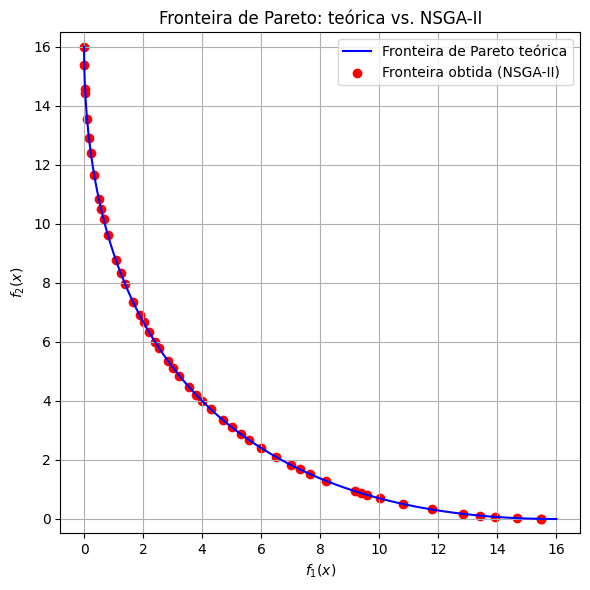

In [9]:
# Executa o NSGA-II e compara com a fronteira de Pareto teórica.
pareto_front = nsga2(pop_size=50, generations=10, bounds=BOUNDS)
plot_pareto(pareto_front, "NSGA-II")

## NSGA-III

O **NSGA-III** (*Non-dominated Sorting Genetic Algorithm III*) é uma extensão do NSGA-II, projetada para a otimização com **muitos objetivos** (tipicamente mais de três). Enquanto o NSGA-II utiliza a *crowding distance* para manter a diversidade, o NSGA-III a substitui por um mecanismo baseado em **pontos de referência** (*reference points*) e **nichos** (*niching*), que distribui as soluções ao longo da fronteira de Pareto de forma mais eficaz em alta dimensionalidade.

A ordenação não dominada e a estrutura elitista (união de pais e descendentes, seleção por fronteiras) permanecem idênticas às do NSGA-II. A diferença está inteiramente na etapa de preservação da diversidade.

### Funcionamento do NSGA-III

1. **Pontos de referência**
   Gera-se um conjunto de pontos uniformemente distribuídos sobre o simplex unitário $z_1 + \dots + z_M = 1$, com $z_m \ge 0$, pelo método de Das–Dennis. Com $p$ divisões por eixo, o número de pontos gerados é

$$
H = \binom{M + p - 1}{p}.
$$

2. **Normalização adaptativa**
   A cada geração, os objetivos são normalizados a partir do **ponto ideal** (mínimo de cada objetivo) e dos **interceptos** do hiperplano determinado pelos pontos extremos, obtidos por minimização de uma função de escalarização (ASF). Isso torna o método robusto a diferentes escalas dos objetivos.

3. **Associação aos pontos de referência**
   Cada solução normalizada é associada à **direção de referência mais próxima**, medida pela distância perpendicular entre a solução e a reta que parte da origem na direção do ponto de referência.

4. **Preservação da diversidade por *niching***
   Na seleção ambiental, quando uma fronteira não cabe integralmente, escolhem-se soluções da última fronteira privilegiando os pontos de referência **menos ocupados** (*niche count* $\rho_j$). Isso mantém uma cobertura uniforme da fronteira, sem depender da *crowding distance*.

No código a seguir, aplicamos o NSGA-III a um problema com **apenas dois objetivos**, para fins de visualização — embora seus benefícios sejam mais evidentes em problemas com muitos objetivos. A implementação segue as etapas canônicas descritas acima.

In [12]:
def nsga3(pop_size, generations, bounds,
          divisions=None, mutation_rate=0.2, mutation_scale=0.05):
    """NSGA-III: pontos de referência + normalização adaptativa + niching.

    O que distingue o NSGA-III (e é implementado aqui) é a preservação da
    diversidade por *niching* em torno de pontos de referência, no lugar da
    crowding distance. A ordenação e a seleção elitista por fronteiras são
    as mesmas do NSGA-II.
    """
    n_obj = len(OBJECTIVES)

    # --- pontos de referência (Das-Dennis) ---------------------------------
    def n_ref(p):
        return math.comb(n_obj + p - 1, p)       # H = C(M + p - 1, p)

    def choose_divisions(target):
        """Escolhe p cujo nº de pontos de referência mais se aproxima de `target`."""
        p = 1
        while n_ref(p) < target:
            p += 1
        candidates = [p] + ([p - 1] if p > 1 else [])
        return min(candidates, key=lambda c: abs(n_ref(c) - target))

    def reference_points(p):
        """Pontos uniformes sobre o simplex z_1 + ... + z_M = 1, z_m >= 0."""
        points = []
        point = [0] * n_obj

        def build(axis, left):
            if axis == n_obj - 1:                # última coordenada recebe o resto
                point[axis] = left
                points.append(np.array(point, dtype=float) / p)
                return
            for value in range(left + 1):
                point[axis] = value
                build(axis + 1, left - value)

        build(0, p)
        return np.vstack(points)

    # --- normalização adaptativa (ideal, extremos por ASF, interceptos) ----
    def normalize(objectives, indices):
        values = np.array([objectives[i] for i in indices], dtype=float)
        translated = values - values.min(axis=0)     # translada o ponto ideal à origem
        eps = 1e-12
        extremes = []
        for m in range(n_obj):                        # ponto extremo de cada eixo (ASF)
            weights = np.full(n_obj, 1e-6)
            weights[m] = 1.0
            extremes.append(translated[np.argmin(np.max(translated / weights, axis=1))])
        extremes = np.asarray(extremes)
        try:                                          # interceptos do hiperplano
            intercepts = 1.0 / np.linalg.solve(extremes, np.ones(n_obj))
            if not np.all(np.isfinite(intercepts)) or np.any(intercepts <= eps):
                raise np.linalg.LinAlgError
        except np.linalg.LinAlgError:                 # alternativa robusta (degenerado)
            intercepts = translated.max(axis=0)
        intercepts = np.where(intercepts > eps, intercepts, 1.0)
        return translated / intercepts

    # --- associação de cada solução à direção de referência mais próxima ---
    def associate(normalized, refs):
        ref_sq = np.sum(refs * refs, axis=1)
        assoc, dists = [], []
        for point in normalized:
            projection = (refs @ point) / ref_sq
            perpendicular = np.linalg.norm(point - projection[:, None] * refs, axis=1)
            j = int(np.argmin(perpendicular))
            assoc.append(j)
            dists.append(float(perpendicular[j]))
        return assoc, dists

    def niching(accepted, last_front, objectives, refs, k):
        """Seleciona k soluções da última fronteira preservando os nichos."""
        considered = accepted + last_front
        normalized = normalize(objectives, considered)
        assoc, dists = associate(normalized, refs)
        pos = {idx: p for p, idx in enumerate(considered)}

        niche_count = [0] * len(refs)                 # rho_j: soluções já aceitas por ref.
        for idx in accepted:
            niche_count[assoc[pos[idx]]] += 1

        candidates = {j: [] for j in range(len(refs))}
        for idx in last_front:
            candidates[assoc[pos[idx]]].append((idx, dists[pos[idx]]))

        selected = []
        active = {j for j, c in candidates.items() if c}
        while len(selected) < k and active:
            min_count = min(niche_count[j] for j in active)
            j = random.choice([r for r in active if niche_count[r] == min_count])
            cand = candidates[j]
            if niche_count[j] == 0:                    # nicho vazio: a mais próxima da ref.
                dmin = min(d for _, d in cand)
                chosen = random.choice([c for c in cand if np.isclose(c[1], dmin)])
            else:                                      # nicho ocupado: qualquer candidata
                chosen = random.choice(cand)
            selected.append(chosen[0])
            cand.remove(chosen)
            niche_count[j] += 1
            if not cand:
                active.remove(j)

        if len(selected) < k:                          # salvaguarda numérica
            rest = [i for i in last_front if i not in set(selected)]
            random.shuffle(rest)
            selected.extend(rest[:k - len(selected)])
        return selected

    def environmental_selection(combined, objectives, fronts, refs):
        """Fronteiras completas enquanto couberem; a última, por niching."""
        accepted, last_front = [], None
        for front in fronts:
            if len(accepted) + len(front) <= pop_size:
                accepted.extend(front)
                if len(accepted) == pop_size:
                    return [combined[i] for i in accepted]
            else:
                last_front = list(front)
                break
        if last_front is None:
            return [combined[i] for i in accepted[:pop_size]]
        chosen = niching(accepted, last_front, objectives, refs,
                         pop_size - len(accepted))
        return [combined[i] for i in accepted + chosen]

    # --- preparação e evolução ---------------------------------------------
    p = divisions if divisions is not None else choose_divisions(pop_size)
    refs = reference_points(p)

    population = initialize_population(pop_size, bounds)
    for _ in range(generations):
        # pais aleatórios: a pressão seletiva vem da seleção ambiental
        offspring = []
        while len(offspring) < pop_size:
            parent1, parent2 = random.sample(population, 2)
            child1, child2 = arithmetic_crossover(parent1, parent2)
            offspring.append(mutate(child1, bounds, mutation_rate, mutation_scale))
            if len(offspring) < pop_size:
                offspring.append(mutate(child2, bounds, mutation_rate, mutation_scale))

        combined = population + offspring
        combined_obj = evaluate_population(combined)
        combined_fronts, _ = fast_nondominated_sort(combined_obj)
        population = environmental_selection(combined, combined_obj,
                                             combined_fronts, refs)

    return extract_pareto_front(population)

A seguir, apresentamos o resultado da execução do NSGA-III, com os pontos obtidos sobrepostos à fronteira de Pareto exata.

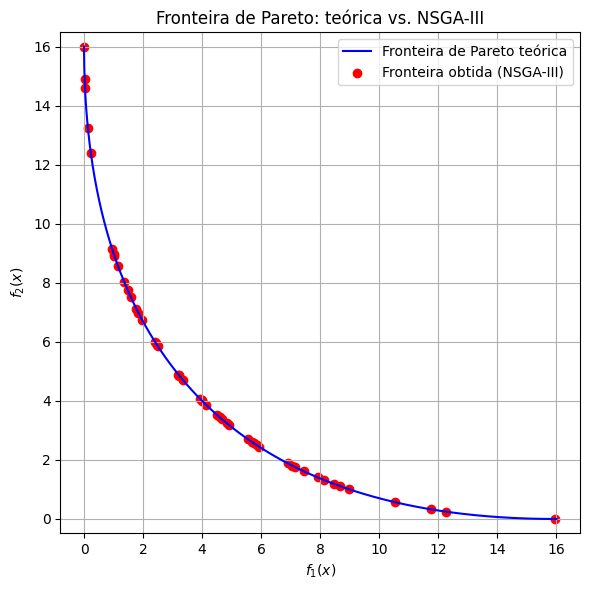

In [13]:
# Executa o NSGA-III e compara com a fronteira de Pareto teórica.
pareto_front = nsga3(pop_size=50, generations=10, bounds=BOUNDS, divisions=10)
plot_pareto(pareto_front, "NSGA-III")

### Resumo da família de algoritmos NSGA

Cada versão do algoritmo NSGA traz avanços importantes:

- **NSGA**: foi inovador ao introduzir o ordenamento não dominado e a função de compartilhamento (*fitness sharing*) para diversidade, mas sofreu com a alta complexidade computacional e a ausência de elitismo.
- **NSGA-II**: tornou o algoritmo mais eficiente e robusto com a introdução do elitismo e da *crowding distance*, tornando-se o padrão para otimização multiobjetivo com até três objetivos.
- **NSGA-III**: ampliou as capacidades do NSGA-II para problemas de muitos objetivos, substituindo a *crowding distance* por uma abordagem baseada em pontos de referência e nichos, que garante boa distribuição de soluções na fronteira de Pareto.

As diferenças entre as três versões refletem a evolução no desenvolvimento de algoritmos evolutivos multiobjetivo. A tabela a seguir apresenta um comparativo geral:


| Característica            | NSGA                          | NSGA-II                     | NSGA-III                                        |
| ------------------------ | ----------------------------- | --------------------------- | ----------------------------------------------- |
| Ordenamento não dominado | $O(MN^3)$, sem elitismo       | $O(MN^2)$, com elitismo     | $O(MN^2)$, com elitismo                         |
| Diversidade              | *Fitness sharing*             | *Crowding distance*         | Pontos de referência e nichos (*niching*)       |
| Eficiência computacional | Baixa                         | Alta para poucos objetivos  | Moderada, com ajuste dos pontos de referência   |
| Aplicabilidade           | Problemas de poucos objetivos | Até três objetivos          | Muitos objetivos (alta dimensionalidade)        |

## Referências

**K. Deb, A. Pratap, S. Agarwal, and T. Meyarivan**, *"A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II,"* IEEE Transactions on Evolutionary Computation, vol. 6, no. 2, pp. 182–197, Apr. 2002.

**K. Deb and H. Jain**, *"An Evolutionary Many-Objective Optimization Algorithm Using Reference-Point-Based Nondominated Sorting Approach, Part I: Solving Problems With Box Constraints,"* in IEEE Transactions on Evolutionary Computation, vol. 18, no. 4, pp. 577–601, Aug. 2014.

**K. Deb**, *"Multi-Objective Optimization Using Evolutionary Algorithms,"* John Wiley & Sons, 2001.